In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score
)
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

print("Libraries loaded successfully")

# ── Load dataset ──────────────────────────────────────────
df = pd.read_csv('../data/creditcard.csv')

print(f"\n=== DATASET OVERVIEW ===")
print(f"Total transactions : {len(df):,}")
print(f"Features           : {df.shape[1]}")
print(f"Fraud cases        : {df['Class'].sum():,}")
print(f"Legitimate cases   : {(df['Class'] == 0).sum():,}")
print(f"Fraud rate         : {df['Class'].mean()*100:.4f}%")
print(f"\nMissing values     : {df.isnull().sum().sum()}")
print(f"\nColumns: {list(df.columns)}")

Libraries loaded successfully

=== DATASET OVERVIEW ===
Total transactions : 284,807
Features           : 31
Fraud cases        : 492
Legitimate cases   : 284,315
Fraud rate         : 0.1727%

Missing values     : 0

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


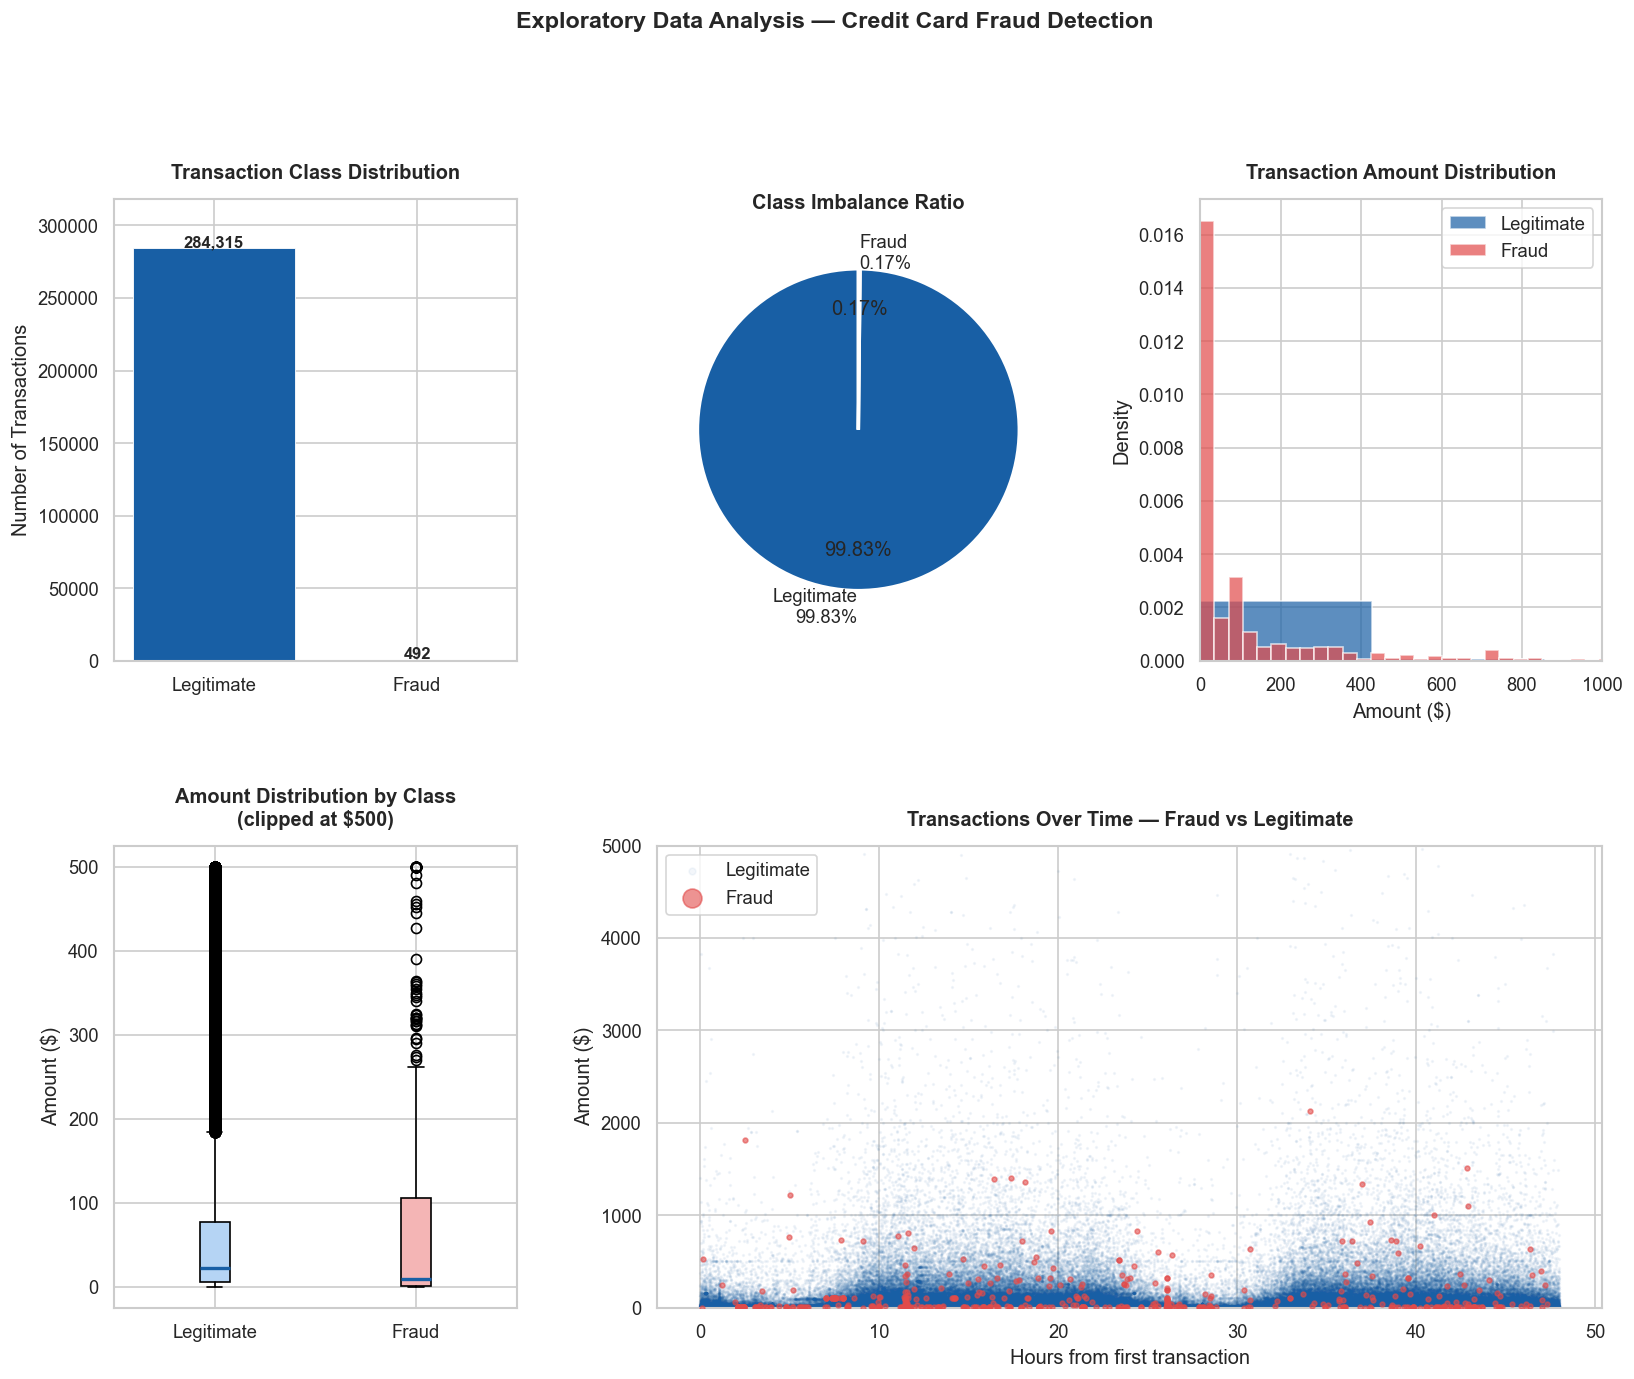

=== AMOUNT STATISTICS BY CLASS ===

Legitimate transactions:
count    284315.00
mean         88.29
std         250.11
min           0.00
25%           5.65
50%          22.00
75%          77.05
max       25691.16
Name: Amount, dtype: float64

Fraud transactions:
count     492.00
mean      122.21
std       256.68
min         0.00
25%         1.00
50%         9.25
75%       105.89
max      2125.87
Name: Amount, dtype: float64

=== KEY INSIGHTS ===
Avg legitimate amount : $88.29
Avg fraud amount      : $122.21
Max fraud amount      : $2125.87
Fraud < $100          : 362 (73.6%)
Fraud < $1,000        : 483 (98.2%)


In [3]:
# ── EDA — Class Distribution & Transaction Amount Analysis ──

fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1. Class distribution — count
ax1 = fig.add_subplot(gs[0, 0])
class_counts = df['Class'].value_counts()
bars = ax1.bar(['Legitimate', 'Fraud'], class_counts.values,
               color=['#185FA5', '#E24B4A'], edgecolor='white', linewidth=0.5)
ax1.set_title('Transaction Class Distribution', fontsize=12, fontweight='bold', pad=12)
ax1.set_ylabel('Number of Transactions')
for bar, val in zip(bars, class_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f'{val:,}', ha='center', fontsize=10, fontweight='bold')
ax1.set_ylim(0, class_counts.max() * 1.12)

# 2. Class distribution — percentage
ax2 = fig.add_subplot(gs[0, 1])
colors = ['#185FA5', '#E24B4A']
wedges, texts, autotexts = ax2.pie(
    class_counts.values,
    labels=['Legitimate\n99.83%', 'Fraud\n0.17%'],
    colors=colors, autopct='%1.2f%%',
    startangle=90, pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax2.set_title('Class Imbalance Ratio', fontsize=12, fontweight='bold', pad=12)

# 3. Transaction amount distribution — legitimate vs fraud
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(df[df['Class']==0]['Amount'], bins=60, alpha=0.7,
         color='#185FA5', label='Legitimate', density=True)
ax3.hist(df[df['Class']==1]['Amount'], bins=60, alpha=0.7,
         color='#E24B4A', label='Fraud', density=True)
ax3.set_title('Transaction Amount Distribution', fontsize=12, fontweight='bold', pad=12)
ax3.set_xlabel('Amount ($)')
ax3.set_ylabel('Density')
ax3.set_xlim(0, 1000)
ax3.legend()

# 4. Amount statistics by class
ax4 = fig.add_subplot(gs[1, 0])
fraud_amounts = df[df['Class']==1]['Amount']
legit_amounts = df[df['Class']==0]['Amount']
bp = ax4.boxplot([legit_amounts.clip(upper=500), fraud_amounts.clip(upper=500)],
                  labels=['Legitimate', 'Fraud'],
                  patch_artist=True,
                  boxprops=dict(facecolor='#E8F0FB'),
                  medianprops=dict(color='#185FA5', linewidth=2))
bp['boxes'][0].set_facecolor('#B5D4F4')
bp['boxes'][1].set_facecolor('#F4B5B5')
ax4.set_title('Amount Distribution by Class\n(clipped at $500)', fontsize=12, fontweight='bold', pad=12)
ax4.set_ylabel('Amount ($)')

# 5. Transactions over time
ax5 = fig.add_subplot(gs[1, 1:])
hours = df['Time'] / 3600
ax5.scatter(hours[df['Class']==0], df[df['Class']==0]['Amount'],
            alpha=0.05, s=1, color='#185FA5', label='Legitimate')
ax5.scatter(hours[df['Class']==1], df[df['Class']==1]['Amount'],
            alpha=0.6, s=8, color='#E24B4A', label='Fraud', zorder=5)
ax5.set_title('Transactions Over Time — Fraud vs Legitimate', fontsize=12, fontweight='bold', pad=12)
ax5.set_xlabel('Hours from first transaction')
ax5.set_ylabel('Amount ($)')
ax5.set_ylim(0, 5000)
ax5.legend(markerscale=4)

plt.suptitle('Exploratory Data Analysis — Credit Card Fraud Detection',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('../img/eda_overview.png', bbox_inches='tight', dpi=150)
plt.show()

# ── Key statistics ──
print("=== AMOUNT STATISTICS BY CLASS ===")
print("\nLegitimate transactions:")
print(df[df['Class']==0]['Amount'].describe().round(2))
print("\nFraud transactions:")
print(df[df['Class']==1]['Amount'].describe().round(2))

print(f"\n=== KEY INSIGHTS ===")
print(f"Avg legitimate amount : ${legit_amounts.mean():.2f}")
print(f"Avg fraud amount      : ${fraud_amounts.mean():.2f}")
print(f"Max fraud amount      : ${fraud_amounts.max():.2f}")
print(f"Fraud < $100          : {(fraud_amounts < 100).sum()} ({(fraud_amounts < 100).mean()*100:.1f}%)")
print(f"Fraud < $1,000        : {(fraud_amounts < 1000).sum()} ({(fraud_amounts < 1000).mean()*100:.1f}%)")

In [4]:
# ── Feature Engineering & Data Preparation ──────────────────

# 1. Scale Amount and Time — V1-V28 are already PCA scaled
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled']   = scaler.fit_transform(df[['Time']])

# 2. Feature engineering — business-relevant variables
df['Hour']            = (df['Time'] / 3600) % 24          # Hour of day (cyclic)
df['Is_night']        = ((df['Hour'] >= 22) | (df['Hour'] <= 6)).astype(int)
df['Amount_log']      = np.log1p(df['Amount'])             # Log transform — reduces skew
df['Is_small_amount'] = (df['Amount'] < 10).astype(int)    # Small amounts — fraud pattern
df['Is_round_amount'] = (df['Amount'] % 1 == 0).astype(int) # Round amounts — fraud pattern

print("=== FEATURE ENGINEERING ===")
print(f"Night transactions (10pm-6am): {df['Is_night'].sum():,} ({df['Is_night'].mean()*100:.1f}%)")
print(f"Small amount (<$10) fraud rate: {df[df['Is_small_amount']==1]['Class'].mean()*100:.3f}%")
print(f"Normal amount fraud rate      : {df[df['Is_small_amount']==0]['Class'].mean()*100:.3f}%")
print(f"Round amount fraud rate       : {df[df['Is_round_amount']==1]['Class'].mean()*100:.3f}%")

# 3. Define features and target
feature_cols = (
    [f'V{i}' for i in range(1, 29)] +
    ['Amount_scaled', 'Time_scaled', 'Amount_log',
     'Is_night', 'Is_small_amount', 'Is_round_amount']
)

X = df[feature_cols]
y = df['Class']

print(f"\n=== DATASET SPLIT ===")
print(f"Features used: {len(feature_cols)}")

# 4. Train/test split — stratified to preserve fraud ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {len(X_train):,} transactions — {y_train.sum()} fraud ({y_train.mean()*100:.3f}%)")
print(f"Test set : {len(X_test):,} transactions — {y_test.sum()} fraud ({y_test.mean()*100:.3f}%)")

# 5. Apply SMOTE to training set only — NEVER to test set
smote = SMOTE(random_state=42, sampling_strategy=0.1)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\n=== AFTER SMOTE (training only) ===")
print(f"Train set: {len(X_train_smote):,} transactions")
print(f"Fraud    : {y_train_smote.sum():,} ({y_train_smote.mean()*100:.2f}%)")
print(f"Legitimate: {(y_train_smote==0).sum():,} ({(y_train_smote==0).mean()*100:.2f}%)")
print(f"\n✅ Test set untouched — {len(X_test):,} real transactions for evaluation")

=== FEATURE ENGINEERING ===
Night transactions (10pm-6am): 50,314 (17.7%)
Small amount (<$10) fraud rate: 0.256%
Normal amount fraud rate      : 0.130%
Round amount fraud rate       : 0.246%

=== DATASET SPLIT ===
Features used: 34
Train set: 227,845 transactions — 394 fraud (0.173%)
Test set : 56,962 transactions — 98 fraud (0.172%)

=== AFTER SMOTE (training only) ===
Train set: 250,196 transactions
Fraud    : 22,745 (9.09%)
Legitimate: 227,451 (90.91%)

✅ Test set untouched — 56,962 real transactions for evaluation


In [5]:
# ── Model Training — Logistic Regression · Random Forest · XGBoost ──

from time import time

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=8, random_state=42,
        n_jobs=-1, class_weight='balanced'
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        scale_pos_weight=(y_train_smote==0).sum() / y_train_smote.sum(),
        random_state=42, eval_metric='logloss',
        use_label_encoder=False
    )
}

results = {}

print("=== MODEL TRAINING ===\n")
for name, model in models.items():
    t0 = time()
    model.fit(X_train_smote, y_train_smote)
    elapsed = time() - t0

    # Predictions
    y_pred      = model.predict(X_test)
    y_prob      = model.predict_proba(X_test)[:, 1]

    # Metrics
    auc_roc     = roc_auc_score(y_test, y_prob)
    avg_prec    = average_precision_score(y_test, y_prob)
    recall      = recall_score(y_test, y_pred)
    precision   = precision_score(y_test, y_pred)
    f1          = f1_score(y_test, y_pred)

    results[name] = {
        'model':     model,
        'y_pred':    y_pred,
        'y_prob':    y_prob,
        'auc_roc':   auc_roc,
        'avg_prec':  avg_prec,
        'recall':    recall,
        'precision': precision,
        'f1':        f1,
        'time':      elapsed
    }

    print(f"{'─'*45}")
    print(f"  {name}")
    print(f"{'─'*45}")
    print(f"  AUC-ROC          : {auc_roc:.4f}")
    print(f"  Avg Precision    : {avg_prec:.4f}")
    print(f"  Recall (fraud)   : {recall:.4f}  ← % fraud detected")
    print(f"  Precision (fraud): {precision:.4f}  ← % alerts that are real fraud")
    print(f"  F1 Score         : {f1:.4f}")
    print(f"  Training time    : {elapsed:.1f}s\n")

print("✅ All models trained.")

=== MODEL TRAINING ===

─────────────────────────────────────────────
  Logistic Regression
─────────────────────────────────────────────
  AUC-ROC          : 0.9697
  Avg Precision    : 0.7148
  Recall (fraud)   : 0.9082  ← % fraud detected
  Precision (fraud): 0.0651  ← % alerts that are real fraud
  F1 Score         : 0.1214
  Training time    : 1.0s

─────────────────────────────────────────────
  Random Forest
─────────────────────────────────────────────
  AUC-ROC          : 0.9823
  Avg Precision    : 0.7891
  Recall (fraud)   : 0.8776  ← % fraud detected
  Precision (fraud): 0.3346  ← % alerts that are real fraud
  F1 Score         : 0.4845
  Training time    : 10.5s

─────────────────────────────────────────────
  XGBoost
─────────────────────────────────────────────
  AUC-ROC          : 0.9759
  Avg Precision    : 0.8237
  Recall (fraud)   : 0.8469  ← % fraud detected
  Precision (fraud): 0.4109  ← % alerts that are real fraud
  F1 Score         : 0.5533
  Training time    : 

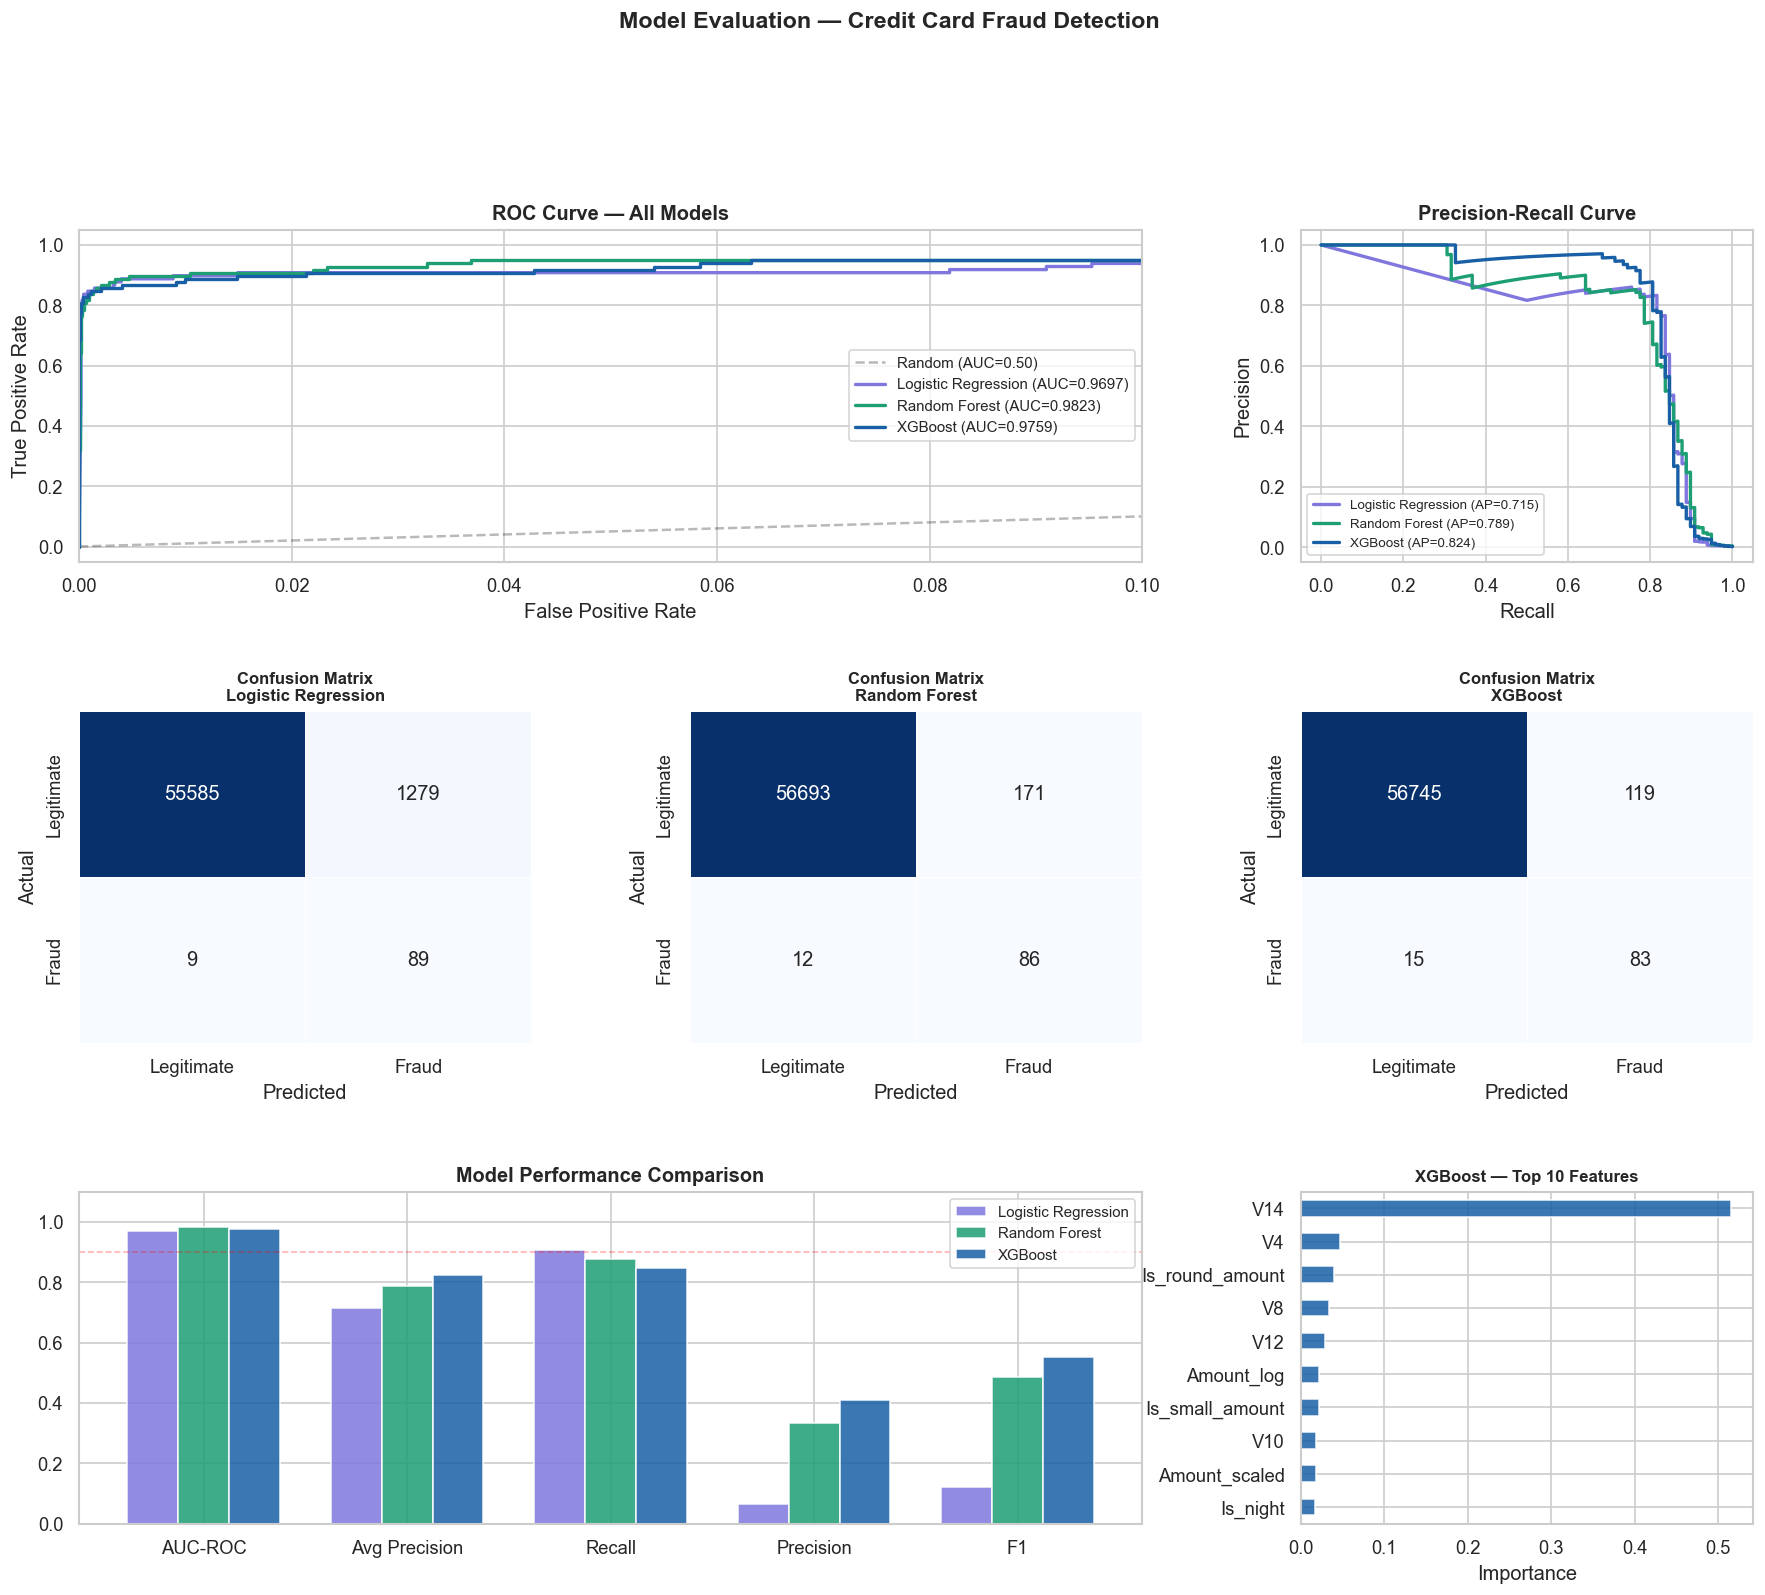

=== CLASSIFICATION REPORTS ===

─────────────────────────────────────────────
  Logistic Regression
─────────────────────────────────────────────
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     56864
       Fraud       0.07      0.91      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.94      0.55     56962
weighted avg       1.00      0.98      0.99     56962

─────────────────────────────────────────────
  Random Forest
─────────────────────────────────────────────
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.33      0.88      0.48        98

    accuracy                           1.00     56962
   macro avg       0.67      0.94      0.74     56962
weighted avg       1.00      1.00      1.00     56962

─────────────────────────────────────────────
  XGBoost
────────────────────────────────────

In [6]:
# ── Model Evaluation & Visualizations ───────────────────────

fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

colors_models = {
    'Logistic Regression': '#7F77DD',
    'Random Forest':       '#1D9E75',
    'XGBoost':             '#185FA5'
}

# ── Row 1: ROC Curves ──
ax_roc = fig.add_subplot(gs[0, 0:2])
ax_roc.plot([0,1], [0,1], 'k--', alpha=0.3, label='Random (AUC=0.50)')
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax_roc.plot(fpr, tpr, color=colors_models[name], linewidth=2,
                label=f"{name} (AUC={res['auc_roc']:.4f})")
ax_roc.set_title('ROC Curve — All Models', fontsize=12, fontweight='bold')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.legend(fontsize=9)
ax_roc.set_xlim([0, 0.1])  # Zoom in on the important region

# ── Precision-Recall Curve ──
ax_pr = fig.add_subplot(gs[0, 2])
for name, res in results.items():
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])
    ax_pr.plot(rec, prec, color=colors_models[name], linewidth=2,
               label=f"{name} (AP={res['avg_prec']:.3f})")
ax_pr.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.legend(fontsize=8)

# ── Row 2: Confusion Matrices ──
for idx, (name, res) in enumerate(results.items()):
    ax_cm = fig.add_subplot(gs[1, idx])
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm,
                xticklabels=['Legitimate', 'Fraud'],
                yticklabels=['Legitimate', 'Fraud'],
                cbar=False, linewidths=0.5)
    ax_cm.set_title(f'Confusion Matrix\n{name}', fontsize=10, fontweight='bold')
    ax_cm.set_ylabel('Actual')
    ax_cm.set_xlabel('Predicted')

# ── Row 3: Metrics comparison ──
ax_metrics = fig.add_subplot(gs[2, 0:2])
metric_names = ['AUC-ROC', 'Avg Precision', 'Recall', 'Precision', 'F1']
x = np.arange(len(metric_names))
width = 0.25
for i, (name, res) in enumerate(results.items()):
    vals = [res['auc_roc'], res['avg_prec'], res['recall'], res['precision'], res['f1']]
    bars = ax_metrics.bar(x + i*width, vals, width, label=name,
                          color=list(colors_models.values())[i], alpha=0.85)
ax_metrics.set_title('Model Performance Comparison', fontsize=12, fontweight='bold')
ax_metrics.set_xticks(x + width)
ax_metrics.set_xticklabels(metric_names)
ax_metrics.set_ylim(0, 1.1)
ax_metrics.legend(fontsize=9)
ax_metrics.axhline(y=0.9, color='red', linestyle='--', alpha=0.3, linewidth=1)

# ── XGBoost Feature Importance ──
ax_fi = fig.add_subplot(gs[2, 2])
xgb_model = results['XGBoost']['model']
importances = pd.Series(xgb_model.feature_importances_, index=feature_cols)
top_features = importances.nlargest(10)
top_features.sort_values().plot(kind='barh', ax=ax_fi, color='#185FA5', alpha=0.85)
ax_fi.set_title('XGBoost — Top 10 Features', fontsize=10, fontweight='bold')
ax_fi.set_xlabel('Importance')

plt.suptitle('Model Evaluation — Credit Card Fraud Detection',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('../img/model_evaluation.png', bbox_inches='tight', dpi=150)
plt.show()

# ── Classification reports ──
print("=== CLASSIFICATION REPORTS ===\n")
for name, res in results.items():
    print(f"{'─'*45}")
    print(f"  {name}")
    print(f"{'─'*45}")
    print(classification_report(y_test, res['y_pred'],
                                target_names=['Legitimate', 'Fraud']))

=== BUSINESS ASSUMPTIONS ===
Avg fraud amount       : $122.21
Avg legitimate amount  : $88.29
Manual review cost     : $5.00 per alert

=== OPTIMAL THRESHOLDS ===
Best F1 threshold      : 0.95
Best net benefit thresh: 0.63
90%+ recall threshold  : 0.07


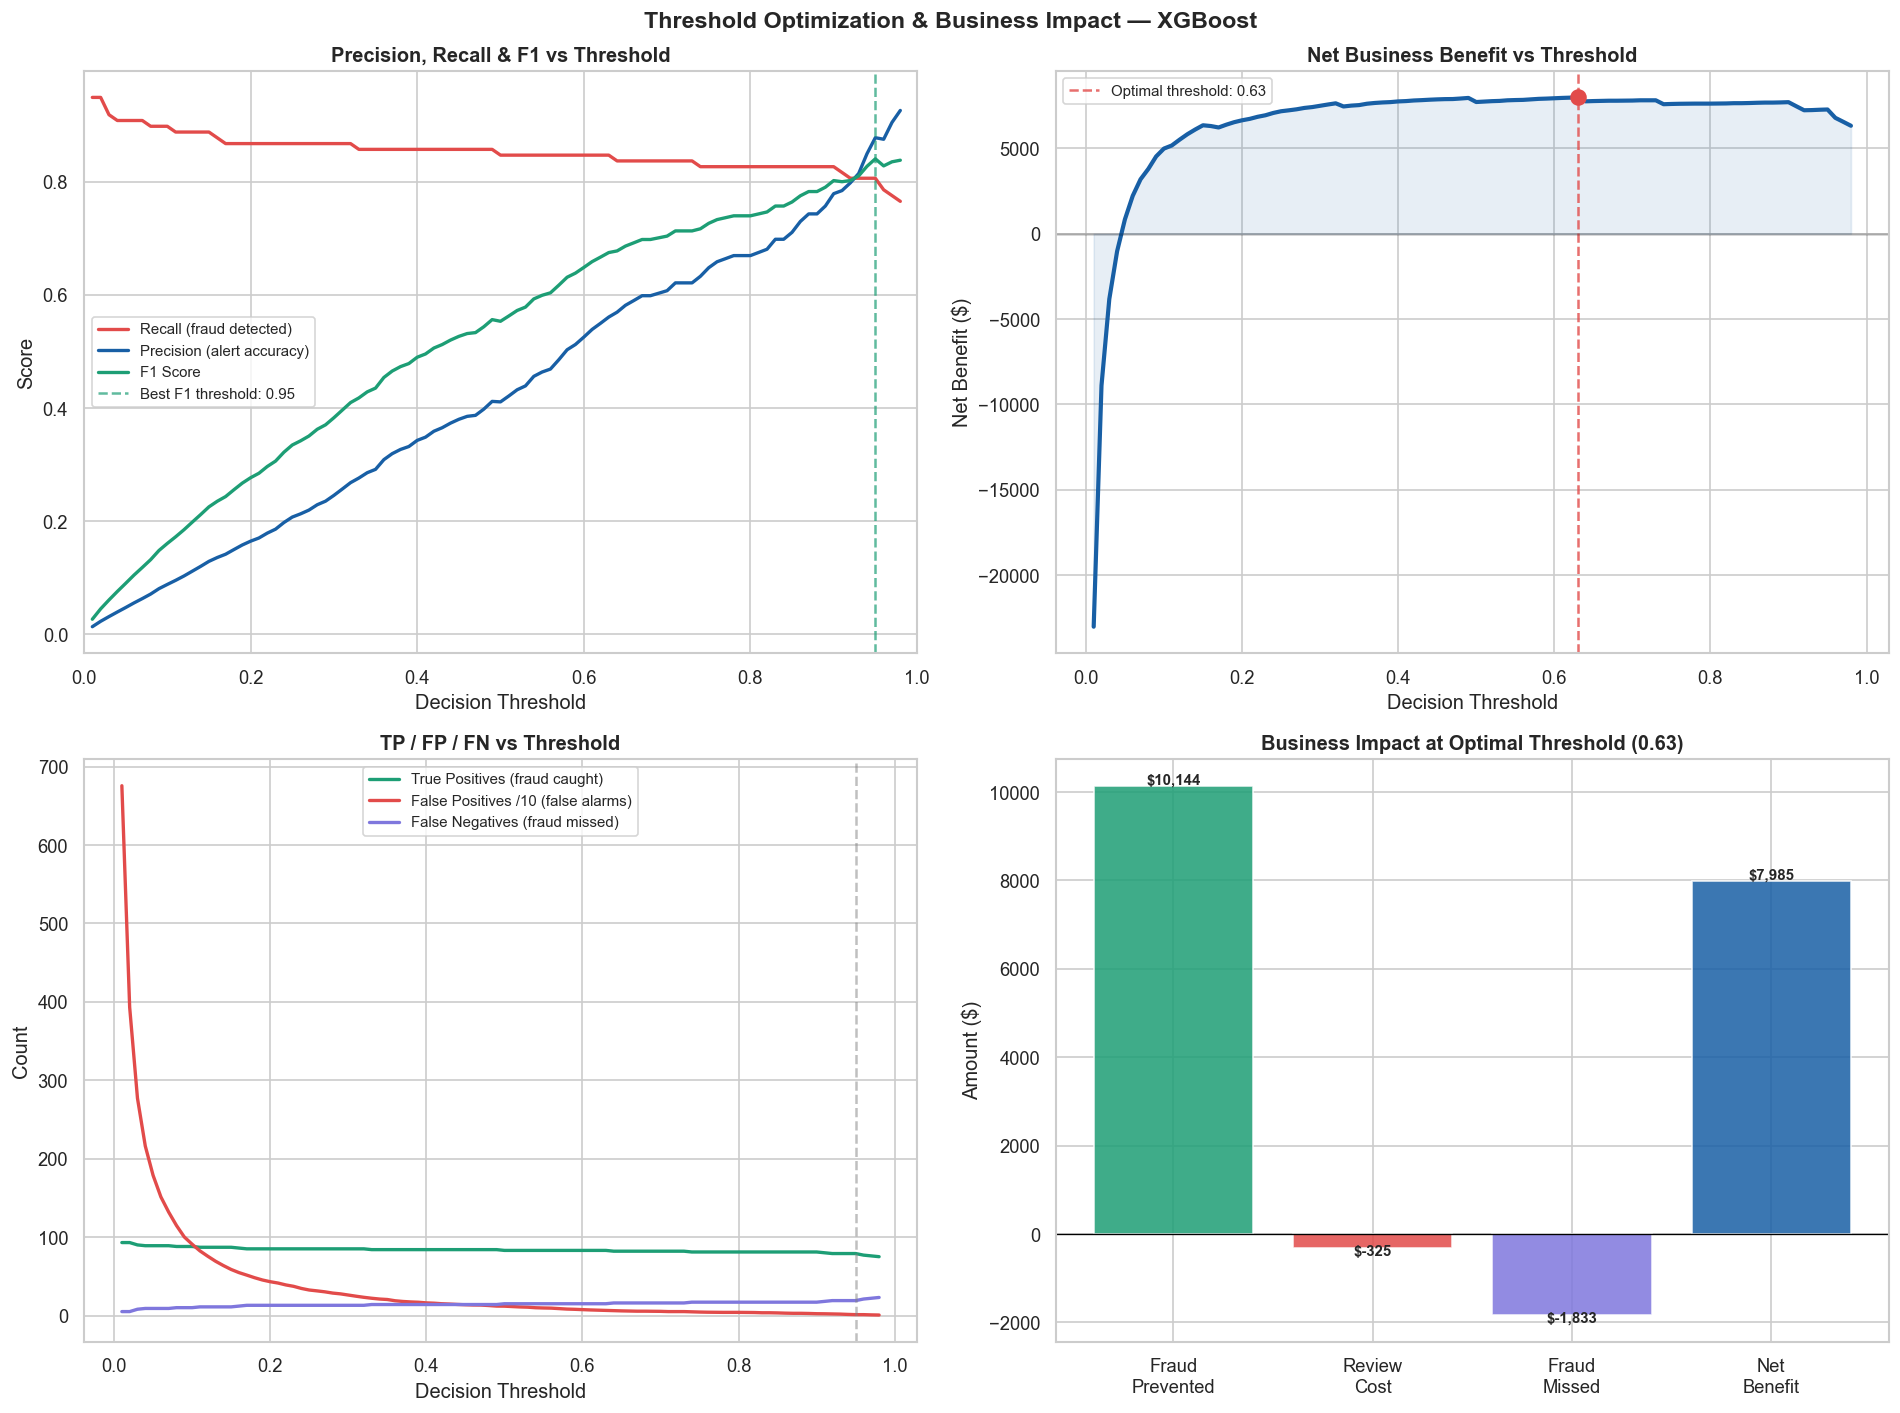


=== RECOMMENDED THRESHOLD: 0.63 ===
Fraud cases detected   : 83/98 (84.7%)
False alarms           : 65
Fraud missed           : 15
Fraud prevented ($)    : $10,143.54
Review cost ($)        : $325.00
Fraud lost ($)         : $1,833.17
NET BENEFIT            : $7,985.37


In [7]:
# ── Threshold Optimization & Business Impact Analysis ────────
# In fraud detection, the default 0.5 threshold is rarely optimal.
# Business decision: what's the cost of missing fraud vs. blocking legit transactions?

# ── Business assumptions (industry standard estimates) ──
AVG_FRAUD_AMOUNT   = df[df['Class']==1]['Amount'].mean()   # avg loss per fraud
AVG_LEGIT_AMOUNT   = df[df['Class']==0]['Amount'].mean()   # avg legit transaction
REVIEW_COST        = 5.0    # cost to manually review a flagged transaction ($)
FRAUD_LOSS_MULT    = 1.0    # multiplier for fraud loss (chargeback + ops cost)

print(f"=== BUSINESS ASSUMPTIONS ===")
print(f"Avg fraud amount       : ${AVG_FRAUD_AMOUNT:.2f}")
print(f"Avg legitimate amount  : ${AVG_LEGIT_AMOUNT:.2f}")
print(f"Manual review cost     : ${REVIEW_COST:.2f} per alert")

# ── Threshold analysis for XGBoost (best model) ──
y_prob_xgb = results['XGBoost']['y_prob']
thresholds  = np.arange(0.01, 0.99, 0.01)

threshold_results = []
for thresh in thresholds:
    y_pred_t = (y_prob_xgb >= thresh).astype(int)
    tp = ((y_pred_t == 1) & (y_test == 1)).sum()  # fraud caught
    fp = ((y_pred_t == 1) & (y_test == 0)).sum()  # false alarms
    fn = ((y_pred_t == 0) & (y_test == 1)).sum()  # fraud missed
    tn = ((y_pred_t == 0) & (y_test == 0)).sum()  # correct legit

    fraud_saved   = tp * AVG_FRAUD_AMOUNT
    review_cost   = fp * REVIEW_COST
    fraud_lost    = fn * AVG_FRAUD_AMOUNT
    net_benefit   = fraud_saved - review_cost - fraud_lost

    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0

    threshold_results.append({
        'threshold':    thresh,
        'recall':       rec,
        'precision':    prec,
        'f1':           f1,
        'tp': tp, 'fp': fp, 'fn': fn,
        'fraud_saved':  fraud_saved,
        'review_cost':  review_cost,
        'fraud_lost':   fraud_lost,
        'net_benefit':  net_benefit
    })

df_thresh = pd.DataFrame(threshold_results)

# ── Find optimal thresholds ──
best_f1_thresh     = df_thresh.loc[df_thresh['f1'].idxmax(), 'threshold']
best_net_thresh    = df_thresh.loc[df_thresh['net_benefit'].idxmax(), 'threshold']
best_recall_thresh = df_thresh.loc[df_thresh['recall'] >= 0.90, 'threshold'].max()

print(f"\n=== OPTIMAL THRESHOLDS ===")
print(f"Best F1 threshold      : {best_f1_thresh:.2f}")
print(f"Best net benefit thresh: {best_net_thresh:.2f}")
print(f"90%+ recall threshold  : {best_recall_thresh:.2f}")

# ── Visualization ──
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Threshold Optimization & Business Impact — XGBoost',
             fontsize=14, fontweight='bold')

# 1. Precision-Recall vs Threshold
ax1 = axes[0, 0]
ax1.plot(df_thresh['threshold'], df_thresh['recall'],
         color='#E24B4A', linewidth=2, label='Recall (fraud detected)')
ax1.plot(df_thresh['threshold'], df_thresh['precision'],
         color='#185FA5', linewidth=2, label='Precision (alert accuracy)')
ax1.plot(df_thresh['threshold'], df_thresh['f1'],
         color='#1D9E75', linewidth=2, label='F1 Score')
ax1.axvline(best_f1_thresh, color='#1D9E75', linestyle='--', alpha=0.7,
            label=f'Best F1 threshold: {best_f1_thresh:.2f}')
ax1.set_title('Precision, Recall & F1 vs Threshold', fontweight='bold')
ax1.set_xlabel('Decision Threshold')
ax1.set_ylabel('Score')
ax1.legend(fontsize=9)
ax1.set_xlim([0, 1])

# 2. Net Business Benefit vs Threshold
ax2 = axes[0, 1]
ax2.plot(df_thresh['threshold'], df_thresh['net_benefit'],
         color='#185FA5', linewidth=2.5)
ax2.fill_between(df_thresh['threshold'], df_thresh['net_benefit'],
                 alpha=0.1, color='#185FA5')
ax2.axvline(best_net_thresh, color='#E24B4A', linestyle='--', alpha=0.8,
            label=f'Optimal threshold: {best_net_thresh:.2f}')
ax2.axhline(0, color='black', linestyle='-', alpha=0.2)
best_net = df_thresh.loc[df_thresh['net_benefit'].idxmax(), 'net_benefit']
ax2.scatter([best_net_thresh], [best_net], color='#E24B4A', s=80, zorder=5)
ax2.set_title('Net Business Benefit vs Threshold', fontweight='bold')
ax2.set_xlabel('Decision Threshold')
ax2.set_ylabel('Net Benefit ($)')
ax2.legend(fontsize=9)

# 3. TP / FP / FN vs Threshold
ax3 = axes[1, 0]
ax3.plot(df_thresh['threshold'], df_thresh['tp'],
         color='#1D9E75', linewidth=2, label='True Positives (fraud caught)')
ax3.plot(df_thresh['threshold'], df_thresh['fp']/10,
         color='#E24B4A', linewidth=2, label='False Positives /10 (false alarms)')
ax3.plot(df_thresh['threshold'], df_thresh['fn'],
         color='#7F77DD', linewidth=2, label='False Negatives (fraud missed)')
ax3.axvline(best_f1_thresh, color='gray', linestyle='--', alpha=0.5)
ax3.set_title('TP / FP / FN vs Threshold', fontweight='bold')
ax3.set_xlabel('Decision Threshold')
ax3.set_ylabel('Count')
ax3.legend(fontsize=9)

# 4. Business impact breakdown at optimal threshold
ax4 = axes[1, 1]
opt = df_thresh.loc[df_thresh['net_benefit'].idxmax()]
categories = ['Fraud\nPrevented', 'Review\nCost', 'Fraud\nMissed', 'Net\nBenefit']
values = [opt['fraud_saved'], -opt['review_cost'], -opt['fraud_lost'], opt['net_benefit']]
bar_colors = ['#1D9E75', '#E24B4A', '#7F77DD', '#185FA5']
bars = ax4.bar(categories, values, color=bar_colors, alpha=0.85, edgecolor='white')
ax4.axhline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, values):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (50 if val >= 0 else -150),
             f'${val:,.0f}', ha='center', fontsize=9, fontweight='bold')
ax4.set_title(f'Business Impact at Optimal Threshold ({best_net_thresh:.2f})',
              fontweight='bold')
ax4.set_ylabel('Amount ($)')

plt.tight_layout()
plt.savefig('../img/threshold_optimization.png', bbox_inches='tight', dpi=150)
plt.show()

# ── Final recommendation ──
opt_row = df_thresh.loc[df_thresh['net_benefit'].idxmax()]
print(f"\n=== RECOMMENDED THRESHOLD: {best_net_thresh:.2f} ===")
print(f"Fraud cases detected   : {int(opt_row['tp'])}/98 ({opt_row['recall']*100:.1f}%)")
print(f"False alarms           : {int(opt_row['fp']):,}")
print(f"Fraud missed           : {int(opt_row['fn'])}")
print(f"Fraud prevented ($)    : ${opt_row['fraud_saved']:,.2f}")
print(f"Review cost ($)        : ${opt_row['review_cost']:,.2f}")
print(f"Fraud lost ($)         : ${opt_row['fraud_lost']:,.2f}")
print(f"NET BENEFIT            : ${opt_row['net_benefit']:,.2f}")

=== TRANSACTION SCORING ===
risk_level
Low         283255
Medium         752
Critical       604
High           196
Name: count, dtype: int64

=== FULL DATASET BUSINESS IMPACT ===
Total transactions     : 284,807
Real fraud cases       : 492
Fraud detected         : 477 (97.0%)
False alarms           : 292
Fraud missed           : 15
Fraud prevented        : $58,294.80
Review cost            : $1,460.00
Fraud missed cost      : $1,833.17
NET BENEFIT            : $55,001.63


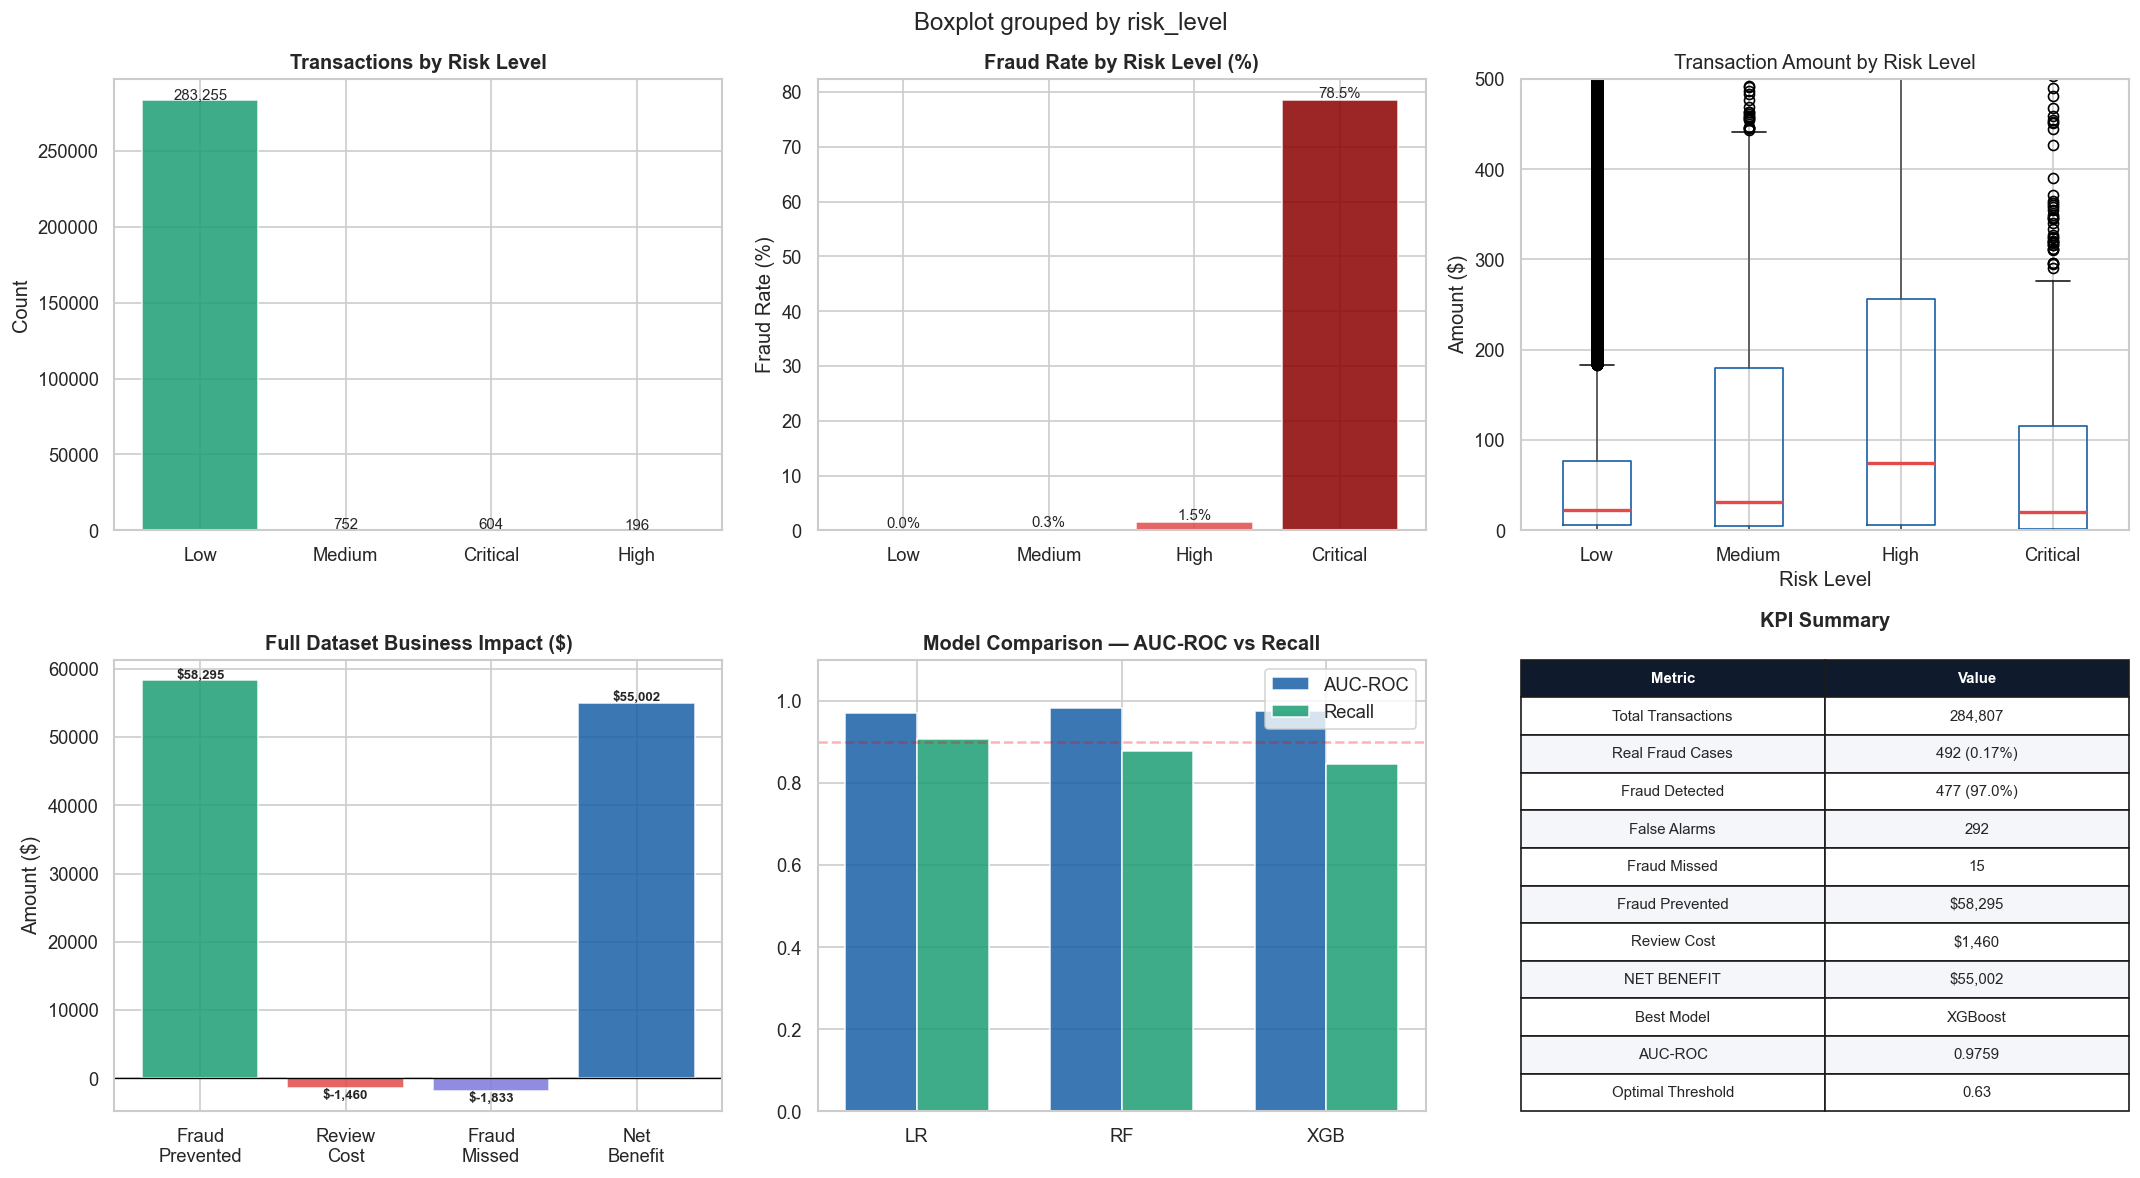


✅ Exported scored_transactions.csv — 284,807 rows


In [8]:
# ── Business Impact Summary & Export for Power BI ────────────

# ── 1. Score all transactions with optimal threshold ──
OPTIMAL_THRESHOLD = best_net_thresh

df['fraud_score']      = results['XGBoost']['model'].predict_proba(X)[:, 1]
df['fraud_predicted']  = (df['fraud_score'] >= OPTIMAL_THRESHOLD).astype(int)
df['risk_level']       = pd.cut(
    df['fraud_score'],
    bins=[0, 0.3, 0.6, 0.8, 1.0],
    labels=['Low', 'Medium', 'High', 'Critical']
)

print("=== TRANSACTION SCORING ===")
print(df['risk_level'].value_counts())

# ── 2. Business impact at scale ──
total_transactions = len(df)
fraud_real         = df['Class'].sum()
fraud_detected     = ((df['fraud_predicted'] == 1) & (df['Class'] == 1)).sum()
false_alarms       = ((df['fraud_predicted'] == 1) & (df['Class'] == 0)).sum()
fraud_missed       = ((df['fraud_predicted'] == 0) & (df['Class'] == 1)).sum()

fraud_prevented_amt = fraud_detected * AVG_FRAUD_AMOUNT
review_cost_amt     = false_alarms * REVIEW_COST
fraud_missed_amt    = fraud_missed * AVG_FRAUD_AMOUNT
net_benefit_amt     = fraud_prevented_amt - review_cost_amt - fraud_missed_amt

print(f"\n=== FULL DATASET BUSINESS IMPACT ===")
print(f"Total transactions     : {total_transactions:,}")
print(f"Real fraud cases       : {fraud_real:,}")
print(f"Fraud detected         : {fraud_detected:,} ({fraud_detected/fraud_real*100:.1f}%)")
print(f"False alarms           : {false_alarms:,}")
print(f"Fraud missed           : {fraud_missed:,}")
print(f"Fraud prevented        : ${fraud_prevented_amt:,.2f}")
print(f"Review cost            : ${review_cost_amt:,.2f}")
print(f"Fraud missed cost      : ${fraud_missed_amt:,.2f}")
print(f"NET BENEFIT            : ${net_benefit_amt:,.2f}")

# ── 3. Executive summary visualization ──
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Executive Summary — Fraud Detection System Performance',
             fontsize=14, fontweight='bold')

# Risk level distribution
ax1 = axes[0, 0]
risk_counts = df['risk_level'].value_counts()
colors_risk = ['#1D9E75', '#EF9F27', '#E24B4A', '#8B0000']
ax1.bar(risk_counts.index, risk_counts.values, color=colors_risk, alpha=0.85)
ax1.set_title('Transactions by Risk Level', fontweight='bold')
ax1.set_ylabel('Count')
for i, (idx, val) in enumerate(risk_counts.items()):
    ax1.text(i, val + 500, f'{val:,}', ha='center', fontsize=9)

# Fraud detection rate by risk level
ax2 = axes[0, 1]
fraud_by_risk = df.groupby('risk_level')['Class'].mean() * 100
ax2.bar(fraud_by_risk.index, fraud_by_risk.values, color=colors_risk, alpha=0.85)
ax2.set_title('Fraud Rate by Risk Level (%)', fontweight='bold')
ax2.set_ylabel('Fraud Rate (%)')
for i, (idx, val) in enumerate(fraud_by_risk.items()):
    ax2.text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=9)

# Amount distribution by risk level
ax3 = axes[0, 2]
df.boxplot(column='Amount', by='risk_level', ax=ax3,
           boxprops=dict(color='#185FA5'),
           medianprops=dict(color='#E24B4A', linewidth=2))
ax3.set_title('Transaction Amount by Risk Level', fontweight='bold')
ax3.set_xlabel('Risk Level')
ax3.set_ylabel('Amount ($)')
ax3.set_ylim(0, 500)
plt.sca(ax3)
plt.title('Transaction Amount by Risk Level')

# Business impact waterfall
ax4 = axes[1, 0]
impact_labels = ['Fraud\nPrevented', 'Review\nCost', 'Fraud\nMissed', 'Net\nBenefit']
impact_values = [fraud_prevented_amt, -review_cost_amt, -fraud_missed_amt, net_benefit_amt]
impact_colors = ['#1D9E75', '#E24B4A', '#7F77DD', '#185FA5']
bars = ax4.bar(impact_labels, impact_values, color=impact_colors, alpha=0.85)
ax4.axhline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, impact_values):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (300 if val >= 0 else -1500),
             f'${val:,.0f}', ha='center', fontsize=8, fontweight='bold')
ax4.set_title('Full Dataset Business Impact ($)', fontweight='bold')
ax4.set_ylabel('Amount ($)')

# Model comparison summary
ax5 = axes[1, 1]
model_names  = list(results.keys())
auc_scores   = [results[m]['auc_roc'] for m in model_names]
recall_scores = [results[m]['recall'] for m in model_names]
x = np.arange(len(model_names))
w = 0.35
ax5.bar(x - w/2, auc_scores, w, label='AUC-ROC', color='#185FA5', alpha=0.85)
ax5.bar(x + w/2, recall_scores, w, label='Recall', color='#1D9E75', alpha=0.85)
ax5.set_title('Model Comparison — AUC-ROC vs Recall', fontweight='bold')
ax5.set_xticks(x)
ax5.set_xticklabels(['LR', 'RF', 'XGB'])
ax5.set_ylim(0, 1.1)
ax5.legend()
ax5.axhline(0.9, color='red', linestyle='--', alpha=0.3)

# KPI summary table
ax6 = axes[1, 2]
ax6.axis('off')
kpi_data = [
    ['Metric', 'Value'],
    ['Total Transactions', f'{total_transactions:,}'],
    ['Real Fraud Cases', f'{fraud_real:,} (0.17%)'],
    ['Fraud Detected', f'{fraud_detected:,} ({fraud_detected/fraud_real*100:.1f}%)'],
    ['False Alarms', f'{false_alarms:,}'],
    ['Fraud Missed', f'{fraud_missed:,}'],
    ['Fraud Prevented', f'${fraud_prevented_amt:,.0f}'],
    ['Review Cost', f'${review_cost_amt:,.0f}'],
    ['NET BENEFIT', f'${net_benefit_amt:,.0f}'],
    ['Best Model', 'XGBoost'],
    ['AUC-ROC', f'{results["XGBoost"]["auc_roc"]:.4f}'],
    ['Optimal Threshold', f'{OPTIMAL_THRESHOLD:.2f}'],
]
table = ax6.table(cellText=kpi_data[1:], colLabels=kpi_data[0],
                  cellLoc='center', loc='center',
                  bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(9)
table[(0,0)].set_facecolor('#0F1B2D')
table[(0,1)].set_facecolor('#0F1B2D')
table[(0,0)].set_text_props(color='white', fontweight='bold')
table[(0,1)].set_text_props(color='white', fontweight='bold')
for i in range(1, len(kpi_data)):
    for j in range(2):
        if i % 2 == 0:
            table[(i,j)].set_facecolor('#F4F6F9')
ax6.set_title('KPI Summary', fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('../img/executive_summary.png', bbox_inches='tight', dpi=150)
plt.show()

# ── 4. Export scored dataset for MySQL & Power BI ──
export_cols = ['Time', 'Amount', 'Class', 'fraud_score', 'fraud_predicted', 'risk_level']
df_export = df[export_cols].copy()
df_export.columns = ['time', 'amount', 'is_fraud', 'fraud_score', 'fraud_predicted', 'risk_level']
df_export['risk_level'] = df_export['risk_level'].astype(str)
df_export.to_csv('../data/scored_transactions.csv', index=False)
print(f"\n✅ Exported scored_transactions.csv — {len(df_export):,} rows")